In [194]:
import numpy as np
import pandas as pd

# Data collection from Kaggle

In [195]:
dataset = pd.read_csv("spam.csv", encoding="latin-1") #Latin-1 is an 8-bit character encoding that supports 256 characters

In [196]:
dataset.head(3)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN


In [197]:
dataset = dataset.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"]) 

# Data Preprocessing

In [198]:
dataset = dataset.rename(columns={"v1":"target", "v2":"text"})

In [199]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [200]:
dataset["target"] = le.fit_transform(dataset["target"]) 

In [201]:
dataset.isnull().sum()

target    0
text      0
dtype: int64

In [202]:
dataset.duplicated().sum()

np.int64(403)

In [203]:
dataset = dataset.drop_duplicates(keep="first")

In [204]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [205]:
from nltk.corpus import stopwords
stopwords = stopwords.words("english")

import string
punctuation = string.punctuation

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [206]:
def trans_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y=[]
    #text = y[:]   #copy
    #y.clear()     #clear
    for i in text:
        if i not in stopwords and i not in punctuation and i.isalnum() :
            y.append(i)
    text=y[:]
    y.clear()
    for i in text :
        y.append(ps.stem(i))
    return " ".join(y)

In [207]:
dataset["transformed_text"] = dataset["text"].apply(trans_text)

In [208]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv  = CountVectorizer()
tfidf = TfidfVectorizer()

In [209]:
X = tfidf.fit_transform(dataset["transformed_text"]).toarray()

In [210]:
Y = dataset["target"]

# Exploratory Data Analysis

In [211]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

In [212]:
wc = WordCloud(width=500,height=500,min_font_size=10,background_color="white")

### spam words

In [213]:
spam_wc = wc.generate(dataset[dataset["target"]==1]["transformed_text"].str.cat(sep=" "))

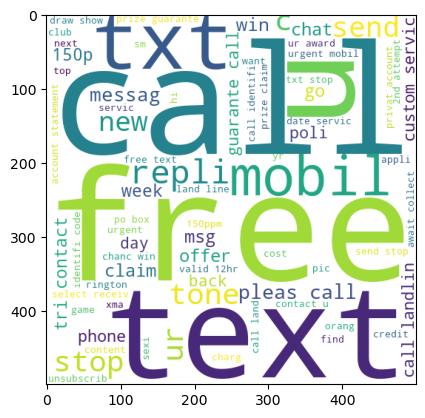

In [214]:
plt.imshow(spam_wc)

### Ham words

In [215]:
ham_wc = wc.generate(dataset[dataset["target"]==0]["transformed_text"].str.cat(sep=" "))

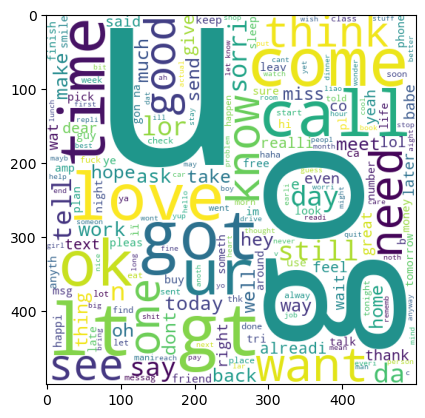

In [216]:
plt.imshow(ham_wc)

### Top 25 spam words

In [217]:
top_spam = []
for msg in dataset[dataset["target"] == 1]["transformed_text"].tolist():
    for word in msg.split():
        top_spam.append(word)

In [218]:
len(top_spam)

9939

<Axes: xlabel='1', ylabel='0'>

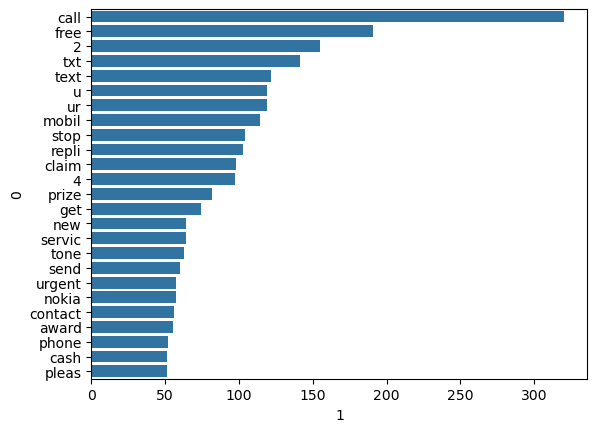

In [219]:
from collections import Counter
ts = pd.DataFrame(Counter(top_spam).most_common(25))
sns.barplot(x=ts[1], y=ts[0])

### Top 25 ham words

In [220]:
top_ham = []
for msg in dataset[dataset["target"] == 0]["transformed_text"].tolist():
    for word in msg.split():
        top_ham.append(word)

In [221]:
len(top_ham)

35404

<Axes: xlabel='1', ylabel='0'>

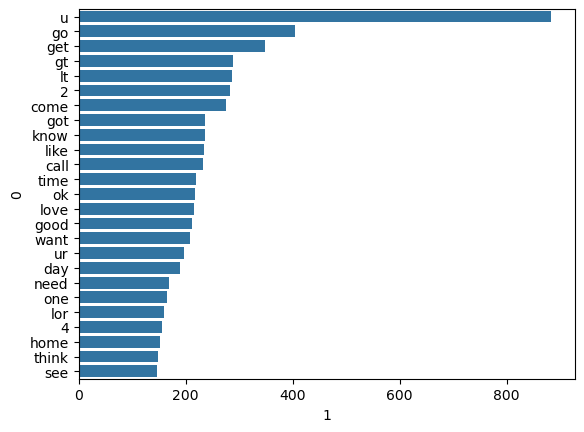

In [222]:
from collections import Counter
th = pd.DataFrame(Counter(top_ham).most_common(25))
sns.barplot(x=th[1], y=th[0])

# Train Test Split

In [223]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

# Model selection and Training

In [224]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [225]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [226]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [227]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8636363636363636
[[772 117]
 [ 24 121]]
0.5084033613445378


In [228]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9613152804642167
[[888   1]
 [ 39 106]]
0.9906542056074766


In [229]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


# Files to download

In [ ]:
#import pickle
#pickle.dump(tfidf,open("vector.pkl","wb"))

In [ ]:
#pickle.dump(mnb,open("spam_model.pkl","wb"))